# 05 - Policy Simulation

Goal: translate causal estimates into a product decision.

The previous notebooks estimated the effect of top-3 ranking exposure on clicks. This notebook asks the next product question:

> If top-3 exposure has different incremental value across segments, how should a ranking team prioritize scarce top positions?

This is not a replacement for an online experiment. It is an offline decision-sizing exercise that uses doubly robust estimates to identify promising policy directions.

## Important Caveat

Logged recommendation data cannot fully tell us what would happen under a new ranking policy. Moving one item into the top 3 necessarily moves another item out, users may respond differently to a changed slate, and some segments overlap with each other.

So this notebook uses a deliberately simple policy simulation:

- Estimate segment-level doubly robust top-3 lift.
- Treat lower-ranked rows as possible promotion opportunities.
- Allocate a limited promotion budget to segments with high estimated lift.
- Compare optimistic and conservative prioritization rules.

The output should be read as a prioritization and sizing tool, not as a final production ranking algorithm.

### Notebook Setup

This cell imports the libraries used for modeling, segment summaries, and policy simulation. The modeling imports mirror notebooks 3 and 4 because this notebook recomputes doubly robust scores independently. That makes it runnable on its own rather than relying on hidden notebook state.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

This cell prepares the notebook environment for policy simulation using segment-level causal lift estimates. There is no substantive model result yet; the important outcome is that the imports and display settings are ready so the next cells can focus on the data and causal question.


### Load The Processed Impression Table

This cell loads the processed MIND-small parquet file. Each row is one displayed item inside an impression. The table includes the treatment (`is_top_3`), outcome (`clicked`), item metadata, and context features needed for causal adjustment and policy simulation.

In [2]:
DATA_RELATIVE_PATH = Path("data/processed/mind_small_impressions_train_sample.parquet")
PROJECT_ROOT = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / DATA_RELATIVE_PATH).exists()
)

DATA_PATH = PROJECT_ROOT / DATA_RELATIVE_PATH
df = pd.read_parquet(DATA_PATH)

df.shape

(737762, 20)

The loaded table preview and shape confirm that the notebook is using the expected processed dataset. This check anchors the rest of the analysis, because all treatment, outcome, and covariate definitions depend on these columns being present and correctly typed.


## Notebook Workflow

The notebook has five parts:

1. Recompute cross-fitted AIPW scores.
2. Estimate segment-level lift for product-relevant segment definitions.
3. Create policy candidates from those segment estimates.
4. Simulate budgeted promotion policies.
5. Produce a product-facing recommendation table.

This repeats some logic from notebook 4 intentionally. Portfolio notebooks are easier to review when each major analysis can run independently.

### Create A Modeling Sample

This cell creates the analysis sample and basic modeling columns. `MODEL_SAMPLE_SIZE` keeps the notebook responsive. The `sample_to_processed_scale` value later lets us roughly scale simulated incremental clicks from the modeling sample back to the processed parquet sample size.

In [3]:
MODEL_SAMPLE_SIZE = 150_000
RANDOM_STATE = 42

model_df = (
    df.sample(n=min(len(df), MODEL_SAMPLE_SIZE), random_state=RANDOM_STATE)
    .reset_index(drop=True)
    .copy()
)

model_df["treatment"] = model_df["is_top_3"].astype(int)
model_df["outcome"] = model_df["clicked"].astype(int)
model_df["log_item_exposures"] = np.log1p(model_df["item_exposures"])
model_df["treatment_label"] = np.where(model_df["treatment"] == 1, "top_3", "rank_4_plus")

sample_to_processed_scale = len(df) / len(model_df)

pd.Series(
    {
        "processed_rows": len(df),
        "model_rows": len(model_df),
        "sample_to_processed_scale": sample_to_processed_scale,
        "treatment_rate_top_3": model_df["treatment"].mean(),
        "click_rate": model_df["outcome"].mean(),
    }
)

processed_rows              737762.0000
model_rows                  150000.0000
sample_to_processed_scale        4.9184
treatment_rate_top_3             0.0801
click_rate                       0.0396
dtype: float64

This cell defines the working analysis sample and standardizes treatment/outcome columns. Fixing this sample early keeps later model comparisons fair because each estimator works on the same rows and target definition.


## Causal Adjustment Setup

The policy simulation depends on estimated segment effects, and those segment effects depend on causal adjustment. We use the same doubly robust approach as notebooks 3 and 4:

- Propensity model: predicts whether a row appears in the top 3.
- Outcome model: predicts click probability from treatment and covariates.
- AIPW score: combines both models into one per-row treatment-effect contribution.

The policy simulation then averages those AIPW scores within segments.

### Define Features For Nuisance Models

This cell defines covariates for the propensity and outcome models. We use user-history, slate-size, text-length, time, exposure, and content metadata features. We avoid `item_clicks` and `item_ctr` as model inputs because they are computed from click outcomes in the same sample and can leak outcome information.

In [4]:
numeric_features = [
    "history_len",
    "candidate_set_size",
    "title_length",
    "abstract_length",
    "hour",
    "day_of_week",
    "log_item_exposures",
]
categorical_features = ["category", "subcategory"]

propensity_features = numeric_features + categorical_features
outcome_numeric_features = numeric_features + ["treatment"]
outcome_features = outcome_numeric_features + categorical_features

X = model_df[propensity_features]
t = model_df["treatment"]

pd.Series(
    {
        "propensity_feature_count": len(propensity_features),
        "outcome_feature_count": len(outcome_features),
        "numeric_feature_count": len(numeric_features),
        "categorical_feature_count": len(categorical_features),
    }
)

propensity_feature_count      9
outcome_feature_count        10
numeric_feature_count         7
categorical_feature_count     2
dtype: int64

The feature lists define what information is allowed into the adjustment models. These are pre-treatment or contextual variables intended to reduce confounding without using the outcome itself as an input.


### Build Logistic Model Pipelines

This cell creates reusable sklearn pipelines. Numeric features are imputed and scaled. Categorical features are imputed and one-hot encoded. Logistic regression is used because it is transparent, fast, and outputs probabilities directly, which is exactly what AIPW needs.

In [5]:
def make_preprocessor(numeric_cols, categorical_cols):
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="infrequent_if_exist",
                    min_frequency=50,
                    sparse_output=True,
                ),
            ),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_cols),
            ("cat", categorical_pipeline, categorical_cols),
        ]
    )


def make_logistic_pipeline(numeric_cols, categorical_cols):
    return Pipeline(
        steps=[
            ("preprocess", make_preprocessor(numeric_cols, categorical_cols)),
            (
                "model",
                LogisticRegression(
                    max_iter=500,
                    solver="lbfgs",
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


base_propensity_model = make_logistic_pipeline(numeric_features, categorical_features)
base_outcome_model = make_logistic_pipeline(outcome_numeric_features, categorical_features)

This cell creates reusable modeling machinery rather than a final result. The value is consistency: the same preprocessing and helper functions can be applied across folds, estimators, and sensitivity checks.


## Cross-Fitted Doubly Robust Scores

The next cells create out-of-fold nuisance predictions. Cross-fitting keeps each row's prediction honest: the row is scored by models that were not trained on that row.

For each row we need:

- `e_hat`: estimated probability of top-3 exposure.
- `mu1_hat`: estimated click probability if the row were top-3.
- `mu0_hat`: estimated click probability if the row were lower-ranked.

These feed into the AIPW score.

### Train Cross-Fitted Propensity And Outcome Models

This cell performs 3-fold cross-fitting. In each fold, it trains models on two-thirds of the sample and predicts the held-out third. The outcome model is used twice on held-out rows: once with treatment forced to 1 and once with treatment forced to 0.

In [6]:
N_FOLDS = 3
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

e_hat = np.zeros(len(model_df))
mu1_hat = np.zeros(len(model_df))
mu0_hat = np.zeros(len(model_df))

propensity_metrics = []
outcome_metrics = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, t), start=1):
    train_df = model_df.iloc[train_idx]
    valid_df = model_df.iloc[valid_idx]

    propensity_model = clone(base_propensity_model)
    propensity_model.fit(train_df[propensity_features], train_df["treatment"])
    e_valid = propensity_model.predict_proba(valid_df[propensity_features])[:, 1]
    e_hat[valid_idx] = e_valid

    outcome_model = clone(base_outcome_model)
    outcome_model.fit(train_df[outcome_features], train_df["outcome"])

    valid_actual = valid_df[outcome_features]
    y_valid_hat = outcome_model.predict_proba(valid_actual)[:, 1]

    valid_treated = valid_df[propensity_features].copy()
    valid_treated["treatment"] = 1
    valid_treated = valid_treated[outcome_features]

    valid_control = valid_df[propensity_features].copy()
    valid_control["treatment"] = 0
    valid_control = valid_control[outcome_features]

    mu1_hat[valid_idx] = outcome_model.predict_proba(valid_treated)[:, 1]
    mu0_hat[valid_idx] = outcome_model.predict_proba(valid_control)[:, 1]

    propensity_metrics.append(
        {
            "fold": fold,
            "roc_auc": roc_auc_score(valid_df["treatment"], e_valid),
            "average_precision": average_precision_score(valid_df["treatment"], e_valid),
            "brier_score": brier_score_loss(valid_df["treatment"], e_valid),
        }
    )
    outcome_metrics.append(
        {
            "fold": fold,
            "roc_auc": roc_auc_score(valid_df["outcome"], y_valid_hat),
            "average_precision": average_precision_score(valid_df["outcome"], y_valid_hat),
            "brier_score": brier_score_loss(valid_df["outcome"], y_valid_hat),
        }
    )

model_df["e_hat"] = e_hat
model_df["mu1_hat"] = mu1_hat
model_df["mu0_hat"] = mu0_hat
model_df["mu_diff_hat"] = model_df["mu1_hat"] - model_df["mu0_hat"]

pd.DataFrame(propensity_metrics)

,fold,roc_auc,average_precision,brier_score
0,1,0.7769,0.3407,0.0660
1,2,0.7622,0.3058,0.0668
2,3,0.7661,0.3205,0.0665


Cross-fitting creates out-of-sample nuisance predictions for treatment and outcome models. This reduces overfitting bias and makes the later doubly robust scores more credible.


### Inspect Outcome Model Metrics

This cell displays fold-level metrics for the click outcome model. These are nuisance-model diagnostics, not the final policy answer. They help us verify that the click model has some signal before using it in the doubly robust score.

In [7]:
pd.DataFrame(outcome_metrics)

,fold,roc_auc,average_precision,brier_score
0,1,0.7119,0.1232,0.0363
1,2,0.6934,0.1111,0.0371
2,3,0.7098,0.1132,0.0368


The nuisance-model metrics show how well the supporting prediction models perform. They are not the causal answer, but weak nuisance models can make IPW, DR, and policy estimates less reliable.


### Compute AIPW Scores

This cell computes one AIPW score per row. The average score is the global doubly robust lift. Segment averages of this score become the segment-level estimated lift used for policy prioritization.

In [8]:
EPS = 0.01

e = model_df["e_hat"].clip(EPS, 1 - EPS).to_numpy()
mu1 = model_df["mu1_hat"].to_numpy()
mu0 = model_df["mu0_hat"].to_numpy()
t_np = model_df["treatment"].to_numpy()
y_np = model_df["outcome"].to_numpy()

model_df["aipw_score"] = (mu1 - mu0) + t_np * (y_np - mu1) / e - (1 - t_np) * (y_np - mu0) / (1 - e)

global_dr_lift = model_df["aipw_score"].mean()
global_dr_se = model_df["aipw_score"].std(ddof=1) / np.sqrt(len(model_df))

pd.Series(
    {
        "global_dr_lift": global_dr_lift,
        "standard_error": global_dr_se,
        "ci_95_lower": global_dr_lift - 1.96 * global_dr_se,
        "ci_95_upper": global_dr_lift + 1.96 * global_dr_se,
    }
)

global_dr_lift   0.0111
standard_error   0.0025
ci_95_lower      0.0062
ci_95_upper      0.0161
dtype: float64

The AIPW score combines outcome-model predictions with propensity-weighted residual corrections. This is the key doubly robust object: it can remain consistent if either the propensity model or the outcome model is correctly specified.


## Segment Effects

Policy simulation needs estimated value by segment. We define several non-overlapping segment dimensions, but we simulate policies one dimension at a time. That avoids double-counting rows across overlapping segment definitions.

### Create Product-Relevant Segment Columns

This cell creates bucketed segment columns. Buckets turn continuous features into interpretable groups. The policy simulation later can allocate budget to segments such as `sports`, `low-history users`, or `high-exposure items`.

In [9]:
model_df["history_bucket"] = pd.cut(
    model_df["history_len"],
    bins=[-1, 0, 10, 30, 100, np.inf],
    labels=["0", "1-10", "11-30", "31-100", "101+"],
)

model_df["candidate_set_bucket"] = pd.cut(
    model_df["candidate_set_size"],
    bins=[0, 10, 25, 50, 100, np.inf],
    labels=["1-10", "11-25", "26-50", "51-100", "101+"],
    include_lowest=True,
)

model_df["item_exposure_quartile"] = pd.qcut(
    model_df["item_exposures"].rank(method="first"),
    q=4,
    labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"],
)

model_df["time_of_day"] = pd.cut(
    model_df["hour"],
    bins=[-1, 5, 11, 16, 20, 23],
    labels=["overnight", "morning", "afternoon", "evening", "late_evening"],
)

segment_columns = [
    "category",
    "subcategory",
    "history_bucket",
    "candidate_set_bucket",
    "item_exposure_quartile",
    "time_of_day",
]

model_df[segment_columns].head()

,category,subcategory,history_bucket,candidate_set_bucket,item_exposure_quartile,time_of_day
0,news,newsworld,31-100,26-50,Q2,afternoon
1,sports,football_ncaa,31-100,51-100,Q2,overnight
2,news,elections-2020-us,31-100,51-100,Q2,afternoon
3,travel,traveltripideas,31-100,51-100,Q3,morning
4,news,newsworld,31-100,51-100,Q2,morning


The segment columns translate raw covariates into product-readable groups. This prepares the analysis for heterogeneity and policy simulation, where segment-level effects are easier to act on than row-level scores.


### Define Segment-Effect Function

This cell defines a helper that estimates segment-level lift. For each segment, it reports row counts, treated/control counts, naive lift, doubly robust lift, confidence intervals, and lower-ranked control rows that could be considered promotion opportunities.

In [10]:
def segment_effects(data, segment_col, min_rows=1_000, min_treated=50, min_control=500):
    rows = []
    for segment_value, group in data.groupby(segment_col, observed=True, dropna=False):
        n_rows = len(group)
        treated_rows = int(group["treatment"].sum())
        control_rows = n_rows - treated_rows

        if n_rows < min_rows or treated_rows < min_treated or control_rows < min_control:
            continue

        treated_ctr = group.loc[group["treatment"] == 1, "outcome"].mean()
        control_ctr = group.loc[group["treatment"] == 0, "outcome"].mean()
        naive_lift = treated_ctr - control_ctr

        scores = group["aipw_score"].to_numpy()
        dr_lift = scores.mean()
        standard_error = scores.std(ddof=1) / np.sqrt(n_rows)

        rows.append(
            {
                "segment_col": segment_col,
                "segment": str(segment_value),
                "rows": n_rows,
                "treated_rows": treated_rows,
                "control_rows": control_rows,
                "treated_ctr": treated_ctr,
                "control_ctr": control_ctr,
                "naive_lift": naive_lift,
                "dr_lift": dr_lift,
                "standard_error": standard_error,
                "ci_95_lower": dr_lift - 1.96 * standard_error,
                "ci_95_upper": dr_lift + 1.96 * standard_error,
                "promotion_opportunities": control_rows,
            }
        )

    return pd.DataFrame(rows).sort_values("dr_lift", ascending=False).reset_index(drop=True)


effect_tables = {
    "category": segment_effects(model_df, "category", min_rows=1_000, min_treated=50, min_control=500),
    "subcategory": segment_effects(model_df, "subcategory", min_rows=1_500, min_treated=75, min_control=750),
    "history_bucket": segment_effects(model_df, "history_bucket", min_rows=1_000, min_treated=50, min_control=500),
    "candidate_set_bucket": segment_effects(model_df, "candidate_set_bucket", min_rows=1_000, min_treated=50, min_control=500),
    "item_exposure_quartile": segment_effects(model_df, "item_exposure_quartile", min_rows=1_000, min_treated=50, min_control=500),
    "time_of_day": segment_effects(model_df, "time_of_day", min_rows=1_000, min_treated=50, min_control=500),
}

pd.Series({name: len(table) for name, table in effect_tables.items()}).rename("segments_available")

category                  14
subcategory               31
history_bucket             5
candidate_set_bucket       5
item_exposure_quartile     4
time_of_day                5
Name: segments_available, dtype: int64

This helper defines how segment-level effects will be computed and filtered. Minimum row, treatment, and control counts keep the segment results from being driven by tiny groups.


### Build A Combined Candidate Table

This cell stacks all segment tables into a single candidate table. `expected_clicks_if_all_opportunities` is a rough sizing calculation: lower-ranked opportunity rows multiplied by estimated segment lift. This says, approximately, how many incremental clicks we would expect if every lower-ranked row in that segment were promoted, ignoring slot competition.

In [11]:
all_candidates = pd.concat(effect_tables.values(), ignore_index=True)
all_candidates["expected_clicks_if_all_opportunities"] = (
    all_candidates["promotion_opportunities"] * all_candidates["dr_lift"].clip(lower=0)
)
all_candidates["conservative_clicks_if_all_opportunities"] = (
    all_candidates["promotion_opportunities"] * all_candidates["ci_95_lower"].clip(lower=0)
)

display_cols = [
    "segment_col",
    "segment",
    "rows",
    "treated_rows",
    "control_rows",
    "dr_lift",
    "ci_95_lower",
    "ci_95_upper",
    "expected_clicks_if_all_opportunities",
    "conservative_clicks_if_all_opportunities",
]

all_candidates[display_cols].sort_values("expected_clicks_if_all_opportunities", ascending=False).head(20)

,segment_col,segment,rows,treated_rows,control_rows,dr_lift,ci_95_lower,ci_95_upper,expected_clicks_if_all_opportunities,conservative_clicks_if_all_opportunities
61,time_of_day,morning,65442,5396,60046,0.0108,0.0032,0.0184,645.8516,189.1933
50,candidate_set_bucket,1-10,5865,3068,2797,0.2275,0.1959,0.2591,636.3183,548.0366
55,item_exposure_quartile,Q4 highest,37500,4525,32975,0.0190,0.0128,0.0253,627.1300,421.3091
45,history_bucket,1-10,39649,3573,36076,0.0168,0.0088,0.0247,605.2458,319.1465
59,time_of_day,afternoon,41771,3354,38417,0.0145,0.0049,0.0242,558.8974,188.9355
47,history_bucket,11-30,49100,3896,45204,0.0102,0.0025,0.0179,459.4557,110.8350
51,candidate_set_bucket,26-50,35116,3030,32086,0.0142,0.0083,0.0202,457.1046,265.4101
56,item_exposure_quartile,Q3,37500,3248,34252,0.0121,0.0018,0.0223,413.3941,62.4486
7,category,news,40583,3685,36898,0.0100,0.0036,0.0165,370.2252,131.3427
48,history_bucket,31-100,47750,3606,44144,0.0080,-0.0020,0.0180,352.1427,0.0000


The candidate table gathers segment-level opportunities into one policy input. This is the bridge from causal estimation to a simulated product decision.


## Budgeted Promotion Simulation

Top-3 slots are scarce. A useful policy question is: if we can promote only a limited number of lower-ranked items, which segments should receive that budget?

We simulate budget allocation within one segmentation dimension at a time. For example, a category policy allocates promotions across categories. A subcategory policy allocates across subcategories. We do not mix dimensions in one allocation because a row can belong to many segment types, which would create double-counting.

### Define Greedy Budget Allocation

This cell defines a simple greedy allocator. It sorts segments by an estimated value column, then allocates promotions to the highest-value positive segments until the budget runs out. The expected incremental clicks are `allocated_promotions * estimated_lift`.

In [12]:
def allocate_budget(effect_df, budget, value_col="dr_lift", min_value=0.0):
    candidates = effect_df.copy()
    candidates = candidates[candidates[value_col] > min_value].sort_values(value_col, ascending=False)

    remaining = int(budget)
    rows = []

    for _, row in candidates.iterrows():
        if remaining <= 0:
            break

        available = int(row["promotion_opportunities"])
        allocated = min(remaining, available)
        if allocated <= 0:
            continue

        rows.append(
            {
                "segment_col": row["segment_col"],
                "segment": row["segment"],
                "allocated_promotions": allocated,
                "value_used": row[value_col],
                "dr_lift": row["dr_lift"],
                "ci_95_lower": row["ci_95_lower"],
                "expected_incremental_clicks": allocated * row[value_col],
            }
        )
        remaining -= allocated

    return pd.DataFrame(rows)

The allocation helper turns estimated segment lift into a budgeted promotion rule. It is deliberately simple and transparent, which makes the later simulation easier to explain.


### Define Promotion Budgets

This cell defines a few budget sizes as percentages of lower-ranked rows in the modeling sample. A 1% budget means we imagine promoting 1% of lower-ranked displayed items into scarce high-visibility positions. These budgets are illustrative knobs, not actual production slot counts.

In [13]:
control_rows = int((model_df["treatment"] == 0).sum())
budget_rates = [0.01, 0.03, 0.05]
budgets = {f"{rate:.0%}_of_lower_ranked_rows": int(control_rows * rate) for rate in budget_rates}

pd.Series(budgets).rename("promotion_budget")

1%_of_lower_ranked_rows    1379
3%_of_lower_ranked_rows    4139
5%_of_lower_ranked_rows    6899
Name: promotion_budget, dtype: int64

The budget definitions set the scale of the simulated intervention. Comparing multiple budgets shows whether expected gains grow smoothly or depend on only a few high-lift segments.


### Simulate Optimistic And Conservative Policies

This cell simulates policies across each segmentation dimension and budget size. There are two value rules:

- `dr_lift`: optimistic expected value, using the point estimate.
- `ci_95_lower`: conservative expected value, using the lower confidence bound.

The conservative rule favors segments where the estimated effect is not only high, but also statistically more stable.

In [14]:
policy_rows = []
allocation_tables = {}

for budget_name, budget in budgets.items():
    for segment_name, effect_df in effect_tables.items():
        for value_col in ["dr_lift", "ci_95_lower"]:
            allocation = allocate_budget(effect_df, budget=budget, value_col=value_col, min_value=0.0)
            policy_name = f"{segment_name}_{value_col}_{budget_name}"
            allocation_tables[policy_name] = allocation

            expected_clicks = allocation["expected_incremental_clicks"].sum() if len(allocation) else 0.0
            allocated_promotions = allocation["allocated_promotions"].sum() if len(allocation) else 0

            policy_rows.append(
                {
                    "policy_name": policy_name,
                    "segment_dimension": segment_name,
                    "value_rule": value_col,
                    "budget_name": budget_name,
                    "budget": budget,
                    "allocated_promotions": allocated_promotions,
                    "expected_incremental_clicks_model_sample": expected_clicks,
                    "expected_incremental_clicks_processed_sample": expected_clicks * sample_to_processed_scale,
                    "avg_incremental_click_prob_per_promotion": expected_clicks / allocated_promotions if allocated_promotions else 0.0,
                }
            )

policy_summary = pd.DataFrame(policy_rows).sort_values(
    "expected_incremental_clicks_model_sample",
    ascending=False,
)

policy_summary.head(20)

,policy_name,segment_dimension,value_rule,budget_name,budget,allocated_promotions,expected_incremental_clicks_model_sample,expected_incremental_clicks_processed_sample,avg_incremental_click_prob_per_promotion
30,candidate_set_bucket_dr_lift_5%_of_lower_ranke...,candidate_set_bucket,dr_lift,5%_of_lower_ranked_rows,6899,6899,694.7564,3417.0990,0.1007
18,candidate_set_bucket_dr_lift_3%_of_lower_ranke...,candidate_set_bucket,dr_lift,3%_of_lower_ranked_rows,4139,4139,655.4368,3223.7090,0.1584
31,candidate_set_bucket_ci_95_lower_5%_of_lower_r...,candidate_set_bucket,ci_95_lower,5%_of_lower_ranked_rows,6899,6899,581.9677,2862.3576,0.0844
19,candidate_set_bucket_ci_95_lower_3%_of_lower_r...,candidate_set_bucket,ci_95_lower,3%_of_lower_ranked_rows,4139,4139,559.1374,2750.0690,0.1351
26,subcategory_dr_lift_5%_of_lower_ranked_rows,subcategory,dr_lift,5%_of_lower_ranked_rows,6899,6899,363.9210,1789.9138,0.0527
6,candidate_set_bucket_dr_lift_1%_of_lower_ranke...,candidate_set_bucket,dr_lift,1%_of_lower_ranked_rows,1379,1379,313.7229,1543.0190,0.2275
7,candidate_set_bucket_ci_95_lower_1%_of_lower_r...,candidate_set_bucket,ci_95_lower,1%_of_lower_ranked_rows,1379,1379,270.1975,1328.9432,0.1959
24,category_dr_lift_5%_of_lower_ranked_rows,category,dr_lift,5%_of_lower_ranked_rows,6899,6899,266.6530,1311.5095,0.0387
14,subcategory_dr_lift_3%_of_lower_ranked_rows,subcategory,dr_lift,3%_of_lower_ranked_rows,4139,4139,233.6357,1149.1169,0.0564
12,category_dr_lift_3%_of_lower_ranked_rows,category,dr_lift,3%_of_lower_ranked_rows,4139,4139,172.4422,848.1421,0.0417


The policy table compares how different decision rules convert segment effects into expected incremental clicks. The conservative version is especially useful because it discounts noisy or uncertain segment estimates.


### Add A Global-Lift Baseline

This cell builds a simple baseline: allocate the same number of promotions without segment targeting and value each promotion at the global doubly robust lift. Segment-targeted policies should beat this baseline to justify extra policy complexity.

In [15]:
baseline_rows = []
for budget_name, budget in budgets.items():
    expected_clicks = budget * max(global_dr_lift, 0)
    baseline_rows.append(
        {
            "policy_name": f"global_dr_lift_baseline_{budget_name}",
            "segment_dimension": "global",
            "value_rule": "global_dr_lift",
            "budget_name": budget_name,
            "budget": budget,
            "allocated_promotions": budget,
            "expected_incremental_clicks_model_sample": expected_clicks,
            "expected_incremental_clicks_processed_sample": expected_clicks * sample_to_processed_scale,
            "avg_incremental_click_prob_per_promotion": expected_clicks / budget if budget else 0.0,
        }
    )

policy_summary_with_baseline = pd.concat(
    [policy_summary, pd.DataFrame(baseline_rows)],
    ignore_index=True,
).sort_values("expected_incremental_clicks_model_sample", ascending=False)

policy_summary_with_baseline.head(20)

,policy_name,segment_dimension,value_rule,budget_name,budget,allocated_promotions,expected_incremental_clicks_model_sample,expected_incremental_clicks_processed_sample,avg_incremental_click_prob_per_promotion
0,candidate_set_bucket_dr_lift_5%_of_lower_ranke...,candidate_set_bucket,dr_lift,5%_of_lower_ranked_rows,6899,6899,694.7564,3417.0990,0.1007
1,candidate_set_bucket_dr_lift_3%_of_lower_ranke...,candidate_set_bucket,dr_lift,3%_of_lower_ranked_rows,4139,4139,655.4368,3223.7090,0.1584
2,candidate_set_bucket_ci_95_lower_5%_of_lower_r...,candidate_set_bucket,ci_95_lower,5%_of_lower_ranked_rows,6899,6899,581.9677,2862.3576,0.0844
3,candidate_set_bucket_ci_95_lower_3%_of_lower_r...,candidate_set_bucket,ci_95_lower,3%_of_lower_ranked_rows,4139,4139,559.1374,2750.0690,0.1351
4,subcategory_dr_lift_5%_of_lower_ranked_rows,subcategory,dr_lift,5%_of_lower_ranked_rows,6899,6899,363.9210,1789.9138,0.0527
5,candidate_set_bucket_dr_lift_1%_of_lower_ranke...,candidate_set_bucket,dr_lift,1%_of_lower_ranked_rows,1379,1379,313.7229,1543.0190,0.2275
6,candidate_set_bucket_ci_95_lower_1%_of_lower_r...,candidate_set_bucket,ci_95_lower,1%_of_lower_ranked_rows,1379,1379,270.1975,1328.9432,0.1959
7,category_dr_lift_5%_of_lower_ranked_rows,category,dr_lift,5%_of_lower_ranked_rows,6899,6899,266.6530,1311.5095,0.0387
8,subcategory_dr_lift_3%_of_lower_ranked_rows,subcategory,dr_lift,3%_of_lower_ranked_rows,4139,4139,233.6357,1149.1169,0.0564
9,category_dr_lift_3%_of_lower_ranked_rows,category,dr_lift,3%_of_lower_ranked_rows,4139,4139,172.4422,848.1421,0.0417


The global baseline provides a simple benchmark: promote lower-ranked rows without segment targeting. Segment policies are only compelling if they improve on this easier baseline.


### Plot Policy Comparison

This cell plots expected incremental clicks for the top policies under the 5% promotion budget. This chart makes the policy comparison easier to read than the full table.

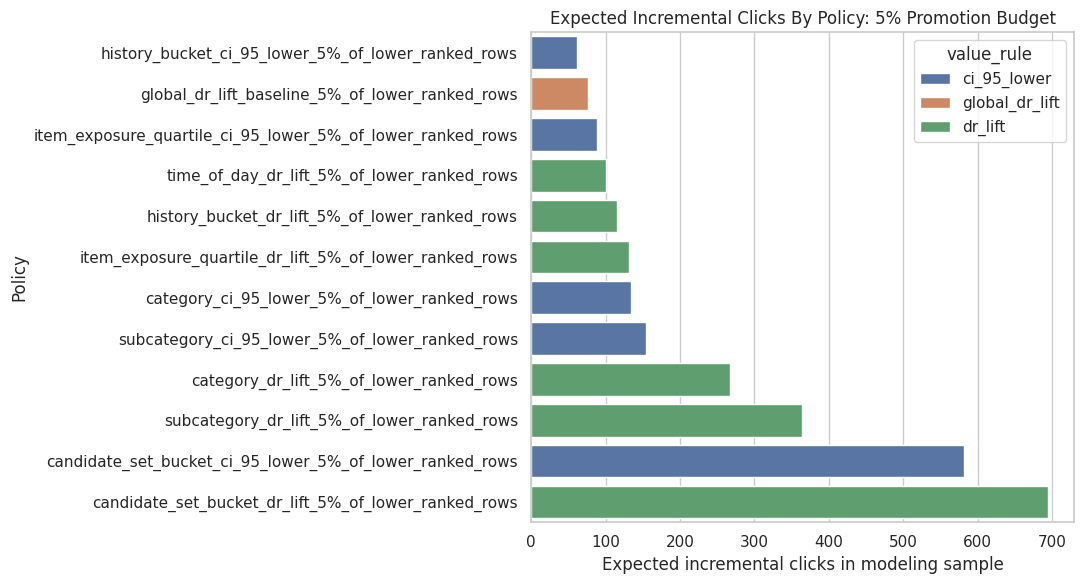

In [16]:
plot_budget = "5%_of_lower_ranked_rows"
plot_df = (
    policy_summary_with_baseline.query("budget_name == @plot_budget")
    .head(12)
    .sort_values("expected_incremental_clicks_model_sample")
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=plot_df,
    x="expected_incremental_clicks_model_sample",
    y="policy_name",
    hue="value_rule",
    dodge=False,
)
plt.title("Expected Incremental Clicks By Policy: 5% Promotion Budget")
plt.xlabel("Expected incremental clicks in modeling sample")
plt.ylabel("Policy")
plt.tight_layout()

The policy plot summarizes the simulated product value of targeted promotion. It helps translate causal lift estimates into the kind of incremental-click story a recommender-system team can evaluate.


## Inspect The Best Policy Allocation

A policy summary tells us which strategy scores best, but we also need to know what that strategy actually allocates to. The next cells inspect the top policy's segment-level allocation.

### Select And Inspect The Best Policy

This cell selects the highest-scoring policy for the 5% budget and displays its allocation table. The allocation table shows which segments receive promotions, how many promotions they receive, and the expected incremental clicks from each segment.

In [17]:
best_policy_row = (
    policy_summary.query("budget_name == @plot_budget")
    .sort_values("expected_incremental_clicks_model_sample", ascending=False)
    .iloc[0]
)
best_policy_name = best_policy_row["policy_name"]
best_allocation = allocation_tables[best_policy_name]

best_policy_row.to_frame().T

,policy_name,segment_dimension,value_rule,budget_name,budget,allocated_promotions,expected_incremental_clicks_model_sample,expected_incremental_clicks_processed_sample,avg_incremental_click_prob_per_promotion
30,candidate_set_bucket_dr_lift_5%_of_lower_ranke...,candidate_set_bucket,dr_lift,5%_of_lower_ranked_rows,6899,6899,694.7564,3417.0990,0.1007


The selected allocation table shows which segments the simulated policy would prioritize. This makes the recommendation actionable and also exposes whether the policy is overly concentrated in a small number of segments.


### Show Best Policy Segment Allocation

This cell displays the segments selected by the best policy. If the policy allocates to only a few segments, that means the estimated value is concentrated. If it spreads across many segments, the value is more diffuse.

In [18]:
best_allocation.head(20)

,segment_col,segment,allocated_promotions,value_used,dr_lift,ci_95_lower,expected_incremental_clicks
0,candidate_set_bucket,1-10,2797,0.2275,0.2275,0.1959,636.3183
1,candidate_set_bucket,26-50,4102,0.0142,0.0142,0.0083,58.4380


The selected allocation table shows which segments the simulated policy would prioritize. This makes the recommendation actionable and also exposes whether the policy is overly concentrated in a small number of segments.


### Inspect The Best Conservative Policy

This cell finds the highest-scoring policy that uses `ci_95_lower` as the value rule. This is a more risk-aware strategy because it prioritizes segments whose lower confidence bounds are positive and large.

In [19]:
best_conservative_row = (
    policy_summary.query("budget_name == @plot_budget and value_rule == 'ci_95_lower'")
    .sort_values("expected_incremental_clicks_model_sample", ascending=False)
    .iloc[0]
)
best_conservative_name = best_conservative_row["policy_name"]
best_conservative_allocation = allocation_tables[best_conservative_name]

best_conservative_row.to_frame().T

,policy_name,segment_dimension,value_rule,budget_name,budget,allocated_promotions,expected_incremental_clicks_model_sample,expected_incremental_clicks_processed_sample,avg_incremental_click_prob_per_promotion
31,candidate_set_bucket_ci_95_lower_5%_of_lower_r...,candidate_set_bucket,ci_95_lower,5%_of_lower_ranked_rows,6899,6899,581.9677,2862.3576,0.0844


The selected allocation table shows which segments the simulated policy would prioritize. This makes the recommendation actionable and also exposes whether the policy is overly concentrated in a small number of segments.


### Show Conservative Allocation

This cell displays the segment allocation for the best conservative policy. This is often the better portfolio recommendation because it is less likely to chase noisy high point estimates.

In [20]:
best_conservative_allocation.head(20)

,segment_col,segment,allocated_promotions,value_used,dr_lift,ci_95_lower,expected_incremental_clicks
0,candidate_set_bucket,1-10,2797,0.1959,0.2275,0.1959,548.0366
1,candidate_set_bucket,26-50,4102,0.0083,0.0142,0.0083,33.9311


The selected allocation table shows which segments the simulated policy would prioritize. This makes the recommendation actionable and also exposes whether the policy is overly concentrated in a small number of segments.


## Budget Sensitivity

A good policy recommendation should not depend on one arbitrary budget. The next cells compare how policy performance changes as the promotion budget increases from 1% to 5% of lower-ranked rows.

### Plot Expected Clicks Across Budgets

This cell plots the best policy from each segment dimension across budget sizes. It shows whether a policy remains attractive as the available promotion budget grows.

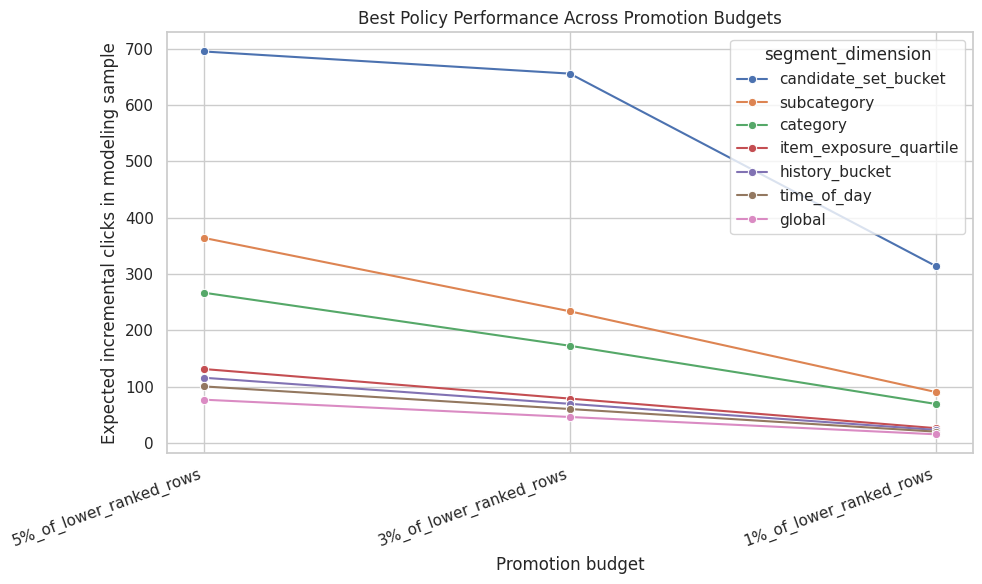

In [21]:
best_by_dimension_budget = (
    policy_summary_with_baseline.sort_values("expected_incremental_clicks_model_sample", ascending=False)
    .groupby(["budget_name", "segment_dimension"], as_index=False)
    .head(1)
)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=best_by_dimension_budget,
    x="budget_name",
    y="expected_incremental_clicks_model_sample",
    hue="segment_dimension",
    marker="o",
)
plt.title("Best Policy Performance Across Promotion Budgets")
plt.xlabel("Promotion budget")
plt.ylabel("Expected incremental clicks in modeling sample")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

The policy plot summarizes the simulated product value of targeted promotion. It helps translate causal lift estimates into the kind of incremental-click story a recommender-system team can evaluate.


### Create Product Recommendation Table

This cell creates a compact table suitable for a product-facing memo. It shows the best policies under the largest budget, their expected incremental clicks, and the scaled estimate for the processed parquet sample.

In [22]:
recommendation_table = (
    policy_summary_with_baseline.query("budget_name == @plot_budget")
    .sort_values("expected_incremental_clicks_model_sample", ascending=False)
    .head(10)
    [[
        "policy_name",
        "segment_dimension",
        "value_rule",
        "budget",
        "allocated_promotions",
        "avg_incremental_click_prob_per_promotion",
        "expected_incremental_clicks_model_sample",
        "expected_incremental_clicks_processed_sample",
    ]]
)

recommendation_table

,policy_name,segment_dimension,value_rule,budget,allocated_promotions,avg_incremental_click_prob_per_promotion,expected_incremental_clicks_model_sample,expected_incremental_clicks_processed_sample
0,candidate_set_bucket_dr_lift_5%_of_lower_ranke...,candidate_set_bucket,dr_lift,6899,6899,0.1007,694.7564,3417.0990
2,candidate_set_bucket_ci_95_lower_5%_of_lower_r...,candidate_set_bucket,ci_95_lower,6899,6899,0.0844,581.9677,2862.3576
4,subcategory_dr_lift_5%_of_lower_ranked_rows,subcategory,dr_lift,6899,6899,0.0527,363.9210,1789.9138
7,category_dr_lift_5%_of_lower_ranked_rows,category,dr_lift,6899,6899,0.0387,266.6530,1311.5095
10,subcategory_ci_95_lower_5%_of_lower_ranked_rows,subcategory,ci_95_lower,6899,6899,0.0224,154.1985,758.4119
11,category_ci_95_lower_5%_of_lower_ranked_rows,category,ci_95_lower,6899,6899,0.0194,134.1387,659.7495
12,item_exposure_quartile_dr_lift_5%_of_lower_ran...,item_exposure_quartile,dr_lift,6899,6899,0.0190,131.2076,645.3331
14,history_bucket_dr_lift_5%_of_lower_ranked_rows,history_bucket,dr_lift,6899,6899,0.0168,115.7443,569.2782
15,time_of_day_dr_lift_5%_of_lower_ranked_rows,time_of_day,dr_lift,6899,6899,0.0145,100.3679,493.6507
17,item_exposure_quartile_ci_95_lower_5%_of_lower...,item_exposure_quartile,ci_95_lower,6899,6899,0.0128,88.1459,433.5381


The recommendation table turns the simulation into product language: which segments to prioritize, what lift is expected, and how much volume is affected. This is the bridge from notebook analysis to stakeholder communication.


## Interpretation Checklist

Use these questions to turn the notebook into a product story:

1. Which segment dimension produces the largest expected incremental clicks?
2. Does the best optimistic policy differ from the best conservative policy?
3. Are expected gains concentrated in a few segments or spread across many?
4. Does the targeted policy beat the global-lift baseline?
5. Are the selected segments large enough to matter operationally?
6. Are the selected segments credible, or are they likely artifacts of noise or unobserved confounding?

A careful portfolio conclusion might be:

`Using doubly robust segment-level estimates, I simulated budgeted top-3 promotion policies. Targeted policies based on segment lift produced higher expected incremental clicks than a global average-lift baseline, with conservative lower-confidence-bound policies offering a more risk-aware recommendation. These offline results identify candidate segments for online experimentation rather than a final production policy.`